In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

In [46]:
df = pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [47]:
print(f"Rows : {df.shape[0]}, Columns : {df.shape[1]}")

Rows : 4888, Columns : 20


In [48]:
df.dtypes

CustomerID                    int64
ProdTaken                     int64
Age                         float64
TypeofContact                   str
CityTier                      int64
DurationOfPitch             float64
Occupation                      str
Gender                          str
NumberOfPersonVisiting        int64
NumberOfFollowups           float64
ProductPitched                  str
PreferredPropertyStar       float64
MaritalStatus                   str
NumberOfTrips               float64
Passport                      int64
PitchSatisfactionScore        int64
OwnCar                        int64
NumberOfChildrenVisiting    float64
Designation                     str
MonthlyIncome               float64
dtype: object

In [49]:
df.sample()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
1519,201519,0,35.0,Self Enquiry,1,14.0,Salaried,Male,2,1.0,Basic,3.0,Married,2.0,0,5,1,1.0,Executive,17269.0


In [50]:
df = df.drop(columns = ['CustomerID'])

In [51]:
df.sample()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
3589,0,37.0,Self Enquiry,1,19.0,Salaried,Female,4,4.0,Deluxe,3.0,Married,2.0,1,1,0,3.0,Manager,23341.0


In [52]:
df.isnull().sum()

ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [53]:
for col in df.columns:
    if df[col].dtype in ['float64','int64']:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
    else:
        most_common = df[col].mode()[0]
        df[col] = df[col].fillna(most_common)

In [54]:
df.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [55]:
print('Dataset shape after cleaning:', df.shape)

Dataset shape after cleaning: (4888, 19)


In [56]:
df.describe()

,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,MonthlyIncome
count,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000,4888.000000
mean,0.188216,37.547259,1.654255,15.362930,2.905074,3.711129,3.577946,3.229746,0.290917,3.078151,0.620295,1.184738,23559.179419
std,0.390925,9.104795,0.916583,8.316166,0.724891,0.998271,0.797005,1.822769,0.454232,1.365792,0.485363,0.852323,5257.862921
min,0.000000,18.000000,1.000000,5.000000,1.000000,1.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1000.000000
25%,0.000000,31.000000,1.000000,9.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,0.000000,1.000000,20485.000000
50%,0.000000,36.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,3.000000,1.000000,1.000000,22347.000000
75%,0.000000,43.000000,3.000000,19.000000,3.000000,4.000000,4.000000,4.000000,1.000000,4.000000,1.000000,2.000000,25424.750000
max,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,5.000000,1.000000,3.000000,98678.000000


Saved: eda_1_target_distribution.png


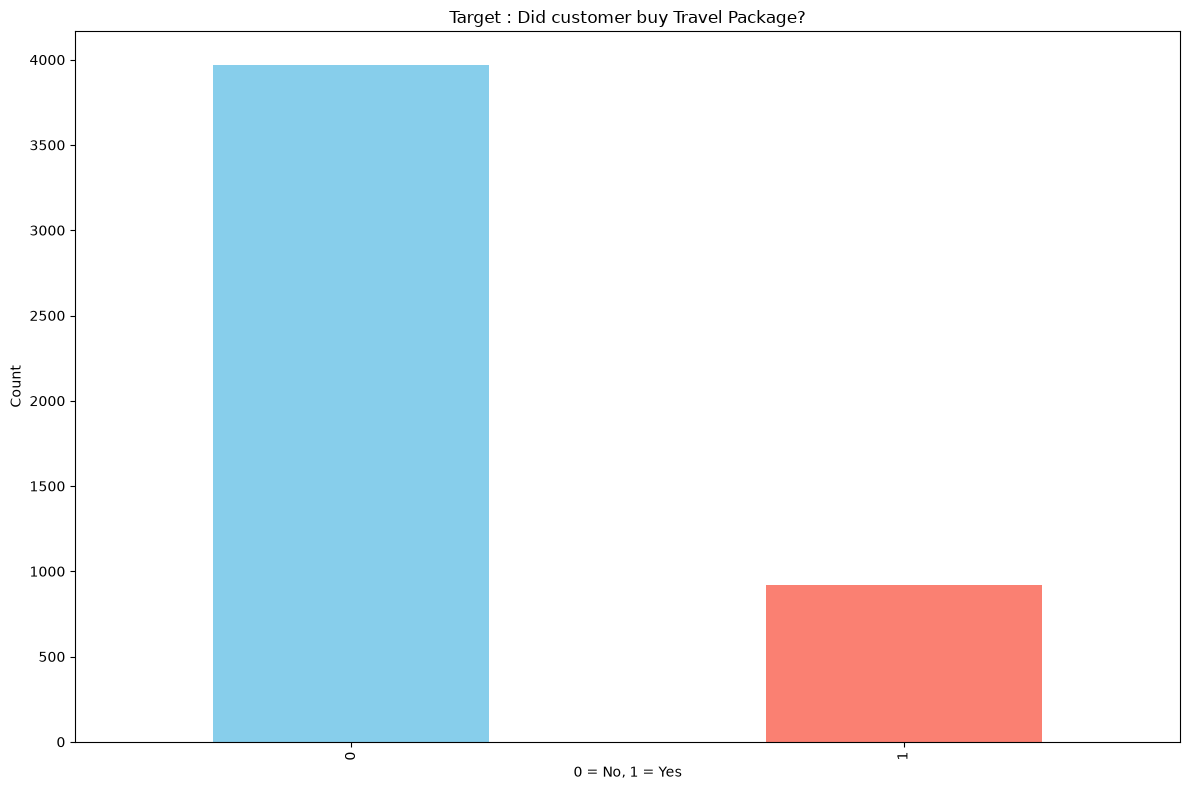

In [57]:
plt.figure(figsize=(12, 8))
df['ProdTaken'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target : Did customer buy Travel Package?')
plt.xlabel("0 = No, 1 = Yes")
plt.ylabel("Count")
plt.xticks()
plt.tight_layout()
plt.savefig('eda_1_target_distribution.png')
print('Saved: eda_1_target_distribution.png')

Saved: eda_2_age_distribution.png


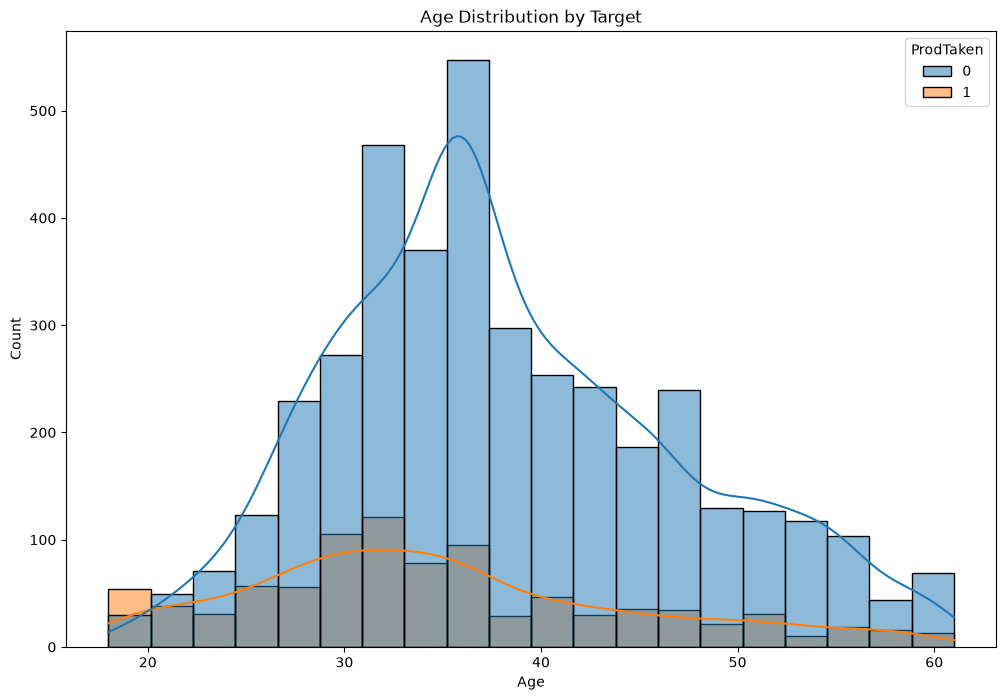

In [58]:
plt.figure(figsize=(12, 8))
sns.histplot(data=df, x='Age', hue='ProdTaken', bins=20, kde=True)
plt.title('Age Distribution by Target')
plt.savefig('eda_2_age_distribution.png')
print('Saved: eda_2_age_distribution.png')

In [59]:
df.sample()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
4419,0,27.0,Self Enquiry,1,13.0,Salaried,Female,4,4.0,Basic,3.0,Married,3.0,1,1,0,2.0,Executive,21337.0


Saved: eda_3_monthly_income_boxplot.png


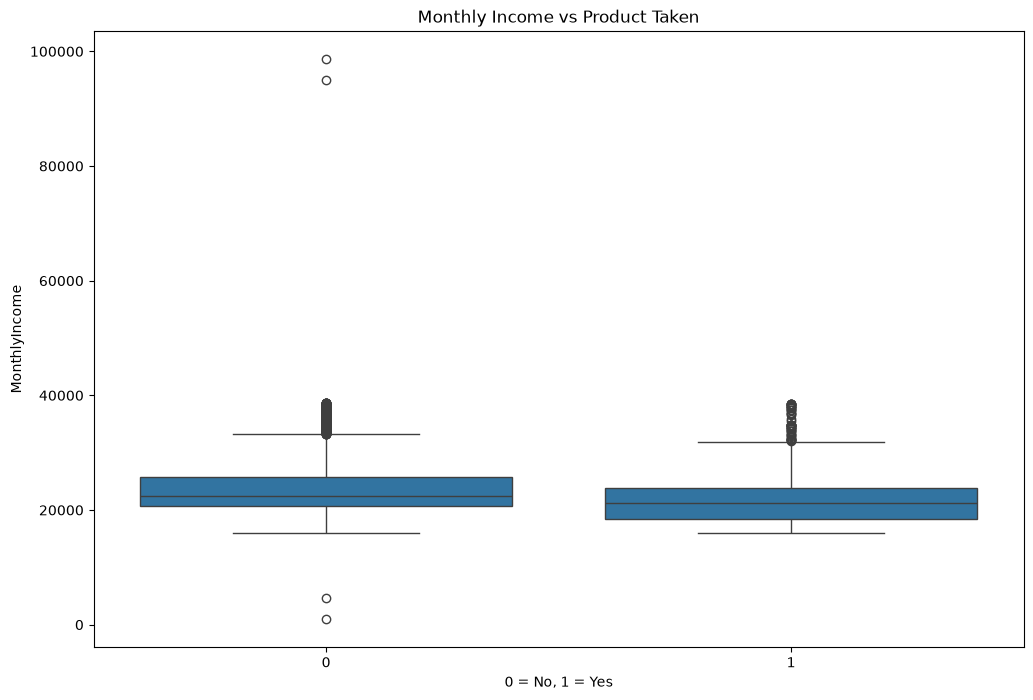

In [60]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='ProdTaken', y='MonthlyIncome')
plt.title('Monthly Income vs Product Taken')
plt.xlabel("0 = No, 1 = Yes")
plt.savefig('eda_3_monthly_income_boxplot.png')
print('Saved: eda_3_monthly_income_boxplot.png')

In [61]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.savefig('eda_4_correlation_matrix.png')
plt.close()
print('Saved: eda_4_correlation_matrix.png')

Saved: eda_4_correlation_matrix.png


In [62]:
text_cols = [col for col in df.columns if df[col].dtype == 'string']
text_cols

['TypeofContact',
 'Occupation',
 'Gender',
 'ProductPitched',
 'MaritalStatus',
 'Designation']

In [63]:
encoders = {}
for col in text_cols:
    col_encoder = LabelEncoder()
    df[col] = col_encoder.fit_transform(df[col])
    encoders[col] = col_encoder
    print(f"Encoded {col} with classes: {col_encoder.classes_}")

Encoded TypeofContact with classes: ['Company Invited' 'Self Enquiry']
Encoded Occupation with classes: ['Free Lancer' 'Large Business' 'Salaried' 'Small Business']
Encoded Gender with classes: ['Fe Male' 'Female' 'Male']
Encoded ProductPitched with classes: ['Basic' 'Deluxe' 'King' 'Standard' 'Super Deluxe']
Encoded MaritalStatus with classes: ['Divorced' 'Married' 'Single' 'Unmarried']
Encoded Designation with classes: ['AVP' 'Executive' 'Manager' 'Senior Manager' 'VP']


In [64]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,1,3,6.0,2,1,3,3.0,1,3.0,2,1.0,1,2,1,0.0,2,20993.0
1,0,49.0,0,1,14.0,2,2,3,4.0,1,4.0,0,2.0,0,3,1,2.0,2,20130.0
2,1,37.0,1,1,8.0,0,2,3,4.0,0,3.0,2,7.0,1,3,0,0.0,1,17090.0
3,0,33.0,0,1,9.0,2,1,2,3.0,0,3.0,0,2.0,1,5,1,1.0,1,17909.0
4,0,36.0,1,1,8.0,3,2,2,3.0,0,4.0,0,1.0,0,5,1,0.0,1,18468.0


In [65]:
X = df.drop(columns=['ProdTaken'])
y = df['ProdTaken']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [67]:
print(f"Training rows: {X_train.shape[0]}, Testing rows: {X_test.shape[0]}")

Training rows: 3910, Testing rows: 978


In [68]:
scaler = StandardScaler()
X_trained_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
X_train_scaled = pd.DataFrame(X_trained_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [70]:
X_train_scaled

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
619,-0.173791,0.642318,1.477328,-1.116889,1.046192,0.788785,-1.256729,-2.708464,-0.147914,1.775141,-0.297105,-0.673593,-0.643510,0.670552,-1.279276,-1.379190,0.285082,-0.229477
1227,-0.173791,0.642318,-0.711099,-0.879814,-0.521092,0.788785,0.128223,-0.708068,-0.928408,-0.729659,-0.297105,-0.673593,-0.643510,1.401078,-1.279276,0.964414,-0.755693,-0.959931
3238,-0.283409,-1.556862,-0.711099,-0.642739,-0.521092,0.788785,0.128223,0.292129,-0.147914,-0.729659,1.856147,-0.673593,-0.643510,-0.790500,0.781692,-0.207388,0.285082,0.541936
3961,0.045445,0.642318,-0.711099,1.253859,-0.521092,0.788785,1.513175,0.292129,-0.928408,0.522741,-0.297105,1.518913,-0.643510,0.670552,-1.279276,0.964414,-0.755693,-0.351596
490,0.045445,0.642318,-0.711099,-1.116889,-0.521092,-1.017980,-1.256729,-0.708068,-0.928408,1.775141,0.779521,0.422660,-0.643510,-0.790500,0.781692,-0.207388,-0.755693,-1.121876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1403,0.155064,0.642318,1.477328,0.661172,1.046192,0.788785,0.128223,-0.708068,2.193566,1.775141,1.856147,-1.221719,-0.643510,-1.521026,0.781692,0.964414,-1.796467,0.901878
492,1.141628,0.642318,-0.711099,-1.116889,-0.521092,-1.017980,-1.256729,0.292129,2.193566,1.775141,-1.373730,-1.221719,-0.643510,0.670552,-1.279276,-0.207388,-1.796467,1.290887
2969,-1.379592,0.642318,1.477328,-0.642739,-0.521092,-1.017980,1.513175,0.292129,-0.147914,-0.729659,1.856147,-0.673593,-0.643510,-0.790500,0.781692,-0.207388,0.285082,-0.058094
2849,-1.269974,0.642318,-0.711099,-0.642739,1.046192,0.788785,1.513175,0.292129,-0.928408,1.775141,-1.373730,2.067039,-0.643510,1.401078,0.781692,0.964414,-0.755693,-0.161150


In [71]:
# (Name, Model, UsedScaledData)
models = [
    ('KNN Classifier', KNeighborsClassifier(n_neighbors=5), True),
    ('LogisticRegression', LogisticRegression(max_iter=1000, random_state=42), True),
    ('Naive Bayes', GaussianNB(), False),
    ('Decision Tree', DecisionTreeClassifier(random_state=42), False),
    ('SVM Classifier', SVC(random_state=42), True),
    ('Random Forest', RandomForestClassifier(random_state=42), False),
    ('AdaBoost', AdaBoostClassifier(random_state=42), False)
]

In [72]:
# Reusing the stratified split from cell 21/23/24 (removed the duplicate, non-stratified re-split that used to live here, since it desynced X_trained_scaled/X_test_scaled from y_train/y_test for the scaled models)

In [73]:
results = {}
for name, model, use_scaled in models:
    if use_scaled:
        X_tr, X_te = X_trained_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test
        
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{'--' * 50}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Taken', 'Taken']))

c:\Users\Acer\Study_work Material\ML Course\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
c:\Users\Acer\Study_work Material\ML Course\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



----------------------------------------------------------------------------------------------------
Model: KNN Classifier
Accuracy: 0.8947

Classification Report:
              precision    recall  f1-score   support

   Not Taken       0.90      0.98      0.94       794
       Taken       0.88      0.51      0.65       184

    accuracy                           0.89       978
   macro avg       0.89      0.75      0.79       978
weighted avg       0.89      0.89      0.88       978


----------------------------------------------------------------------------------------------------
Model: LogisticRegression
Accuracy: 0.8395

Classification Report:
              precision    recall  f1-score   support

   Not Taken       0.85      0.97      0.91       794
       Taken       0.68      0.28      0.40       184

    accuracy                           0.84       978
   macro avg       0.76      0.63      0.65       978
weighted avg       0.82      0.84      0.81       978


-----------

c:\Users\Acer\Study_work Material\ML Course\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(



----------------------------------------------------------------------------------------------------
Model: SVM Classifier
Accuracy: 0.8681

Classification Report:
              precision    recall  f1-score   support

   Not Taken       0.87      0.99      0.92       794
       Taken       0.89      0.34      0.49       184

    accuracy                           0.87       978
   macro avg       0.88      0.67      0.71       978
weighted avg       0.87      0.87      0.84       978


----------------------------------------------------------------------------------------------------
Model: Random Forest
Accuracy: 0.9315

Classification Report:
              precision    recall  f1-score   support

   Not Taken       0.93      0.99      0.96       794
       Taken       0.94      0.68      0.79       184

    accuracy                           0.93       978
   macro avg       0.94      0.83      0.87       978
weighted avg       0.93      0.93      0.93       978


----------------

In [74]:
results

{'KNN Classifier': 0.8946830265848671,
 'LogisticRegression': 0.8394683026584867,
 'Naive Bayes': 0.8282208588957055,
 'Decision Tree': 0.9028629856850716,
 'SVM Classifier': 0.8680981595092024,
 'Random Forest': 0.9314928425357873,
 'AdaBoost': 0.8323108384458078}

Model Comparison Plot: 
Saved: model_comparison.png


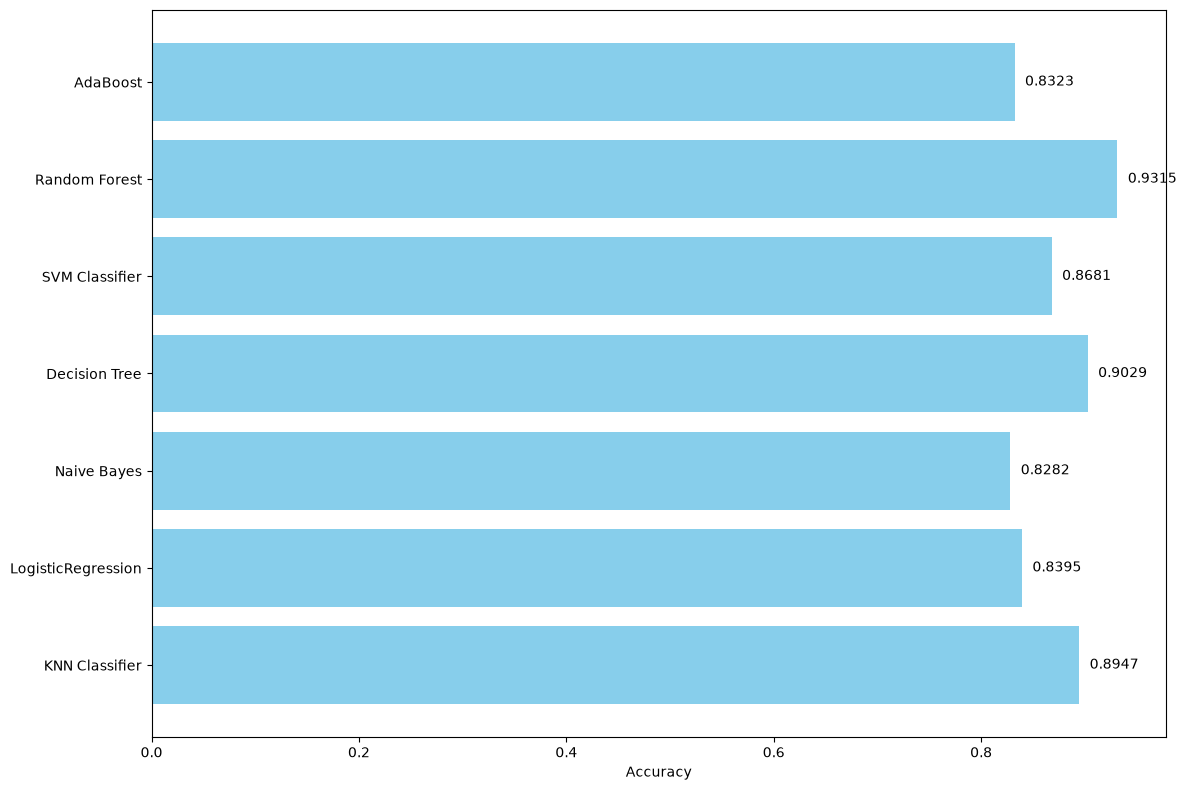

In [75]:
print('Model Comparison Plot: ')
print('=' * 50)
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(12, 8))
bars = plt.barh(model_names, accuracies, color='skyblue')
plt.xlabel('Accuracy')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.4f}', va='center')

plt.tight_layout()
plt.savefig('model_comparison.png')
print('Saved: model_comparison.png')

In [76]:
results

{'KNN Classifier': 0.8946830265848671,
 'LogisticRegression': 0.8394683026584867,
 'Naive Bayes': 0.8282208588957055,
 'Decision Tree': 0.9028629856850716,
 'SVM Classifier': 0.8680981595092024,
 'Random Forest': 0.9314928425357873,
 'AdaBoost': 0.8323108384458078}

In [77]:
best_model_name = max(results, key=results.get)
print(f"Best Model: {best_model_name} with Accuracy: {results[best_model_name]:.4f}")

Best Model: Random Forest with Accuracy: 0.9315


In [78]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

In [79]:
rf_model = RandomForestClassifier(random_state=42)

In [80]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [81]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_pl

In [82]:
print("Best Parameters from Grid Search:", grid_search.best_params_)
print('Best cross-validation accuracy:', grid_search.best_score_)

Best Parameters from Grid Search: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.9063909069364859


In [83]:
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_best)
print(f"Tuned Random Forest Accuracy on Test Set: {tuned_acc:.4f}")
print("\nClassification Report for Tuned Random Forest:")
print(classification_report(y_test, y_pred_best, target_names=['Not Taken', 'Taken']))

Tuned Random Forest Accuracy on Test Set: 0.9335

Classification Report for Tuned Random Forest:
              precision    recall  f1-score   support

   Not Taken       0.93      0.99      0.96       794
       Taken       0.95      0.68      0.79       184

    accuracy                           0.93       978
   macro avg       0.94      0.84      0.88       978
weighted avg       0.93      0.93      0.93       978



Saved: tuned_rf_confusion_matrix.png


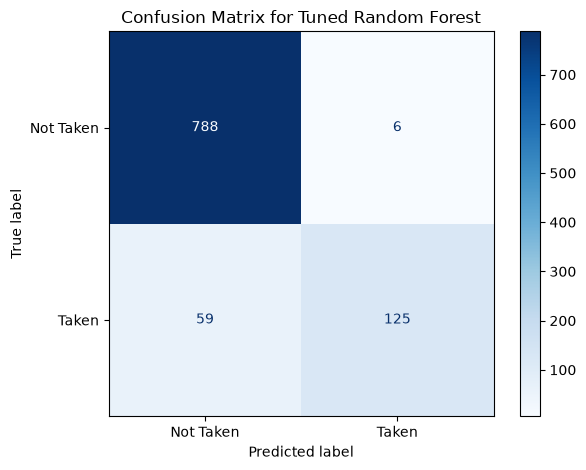

In [84]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Taken', 'Taken'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Tuned Random Forest')
plt.tight_layout()
plt.savefig('tuned_rf_confusion_matrix.png')
print('Saved: tuned_rf_confusion_matrix.png')

In [85]:
joblib.dump(best_rf_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')
print('Saved: best_model.pkl, scaler.pkl, and encoders.pkl')

Saved: best_model.pkl, scaler.pkl, and encoders.pkl


In [86]:
loaded_scaler = joblib.load('scaler.pkl')
loaded_model = joblib.load('best_model.pkl')
loaded_encoders = joblib.load('encoders.pkl')

In [87]:
new_customer = pd.DataFrame({
    'Age': [35],
    'TypeofContact': ['Self Enquiry'],
    'CityTier': [1],
    'DurationOfPitch': [10],
    'Occupation': ['Salaried'],
    'Gender': ['Female'],
    'NumberOfPersonVisiting': [3],
    'NumberOfFollowups': [4],
    'ProductPitched': ['Deluxe'],
    'PreferredPropertyStar': [3],
    'MaritalStatus': ['Single'],
    'NumberOfTrips': [2],
    'Passport': [1],
    'PitchSatisfactionScore': [3],
    'OwnCar': [1],
    'NumberOfChildrenVisiting': [1],
    'Designation': ['Manager'],
    'MonthlyIncome': [22000]
})

# Encode the same categorical columns with the SAME fitted encoders used during training
for col, col_encoder in loaded_encoders.items():
    new_customer[col] = col_encoder.transform(new_customer[col])

# Match the training column order exactly
new_customer = new_customer[X.columns]
new_customer

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,35,1,1,10,2,1,3,4,1,3,2,2,1,3,1,1,2,22000


In [88]:
# best_rf_model was trained on unscaled X_train, so no scaling needed here
prediction = loaded_model.predict(new_customer)[0]
probability = loaded_model.predict_proba(new_customer)[0][1]

print(f"Will this customer take the package? {'Yes' if prediction == 1 else 'No'}")
print(f"Probability of taking the package: {probability:.4f}")

Will this customer take the package? No
Probability of taking the package: 0.0500
